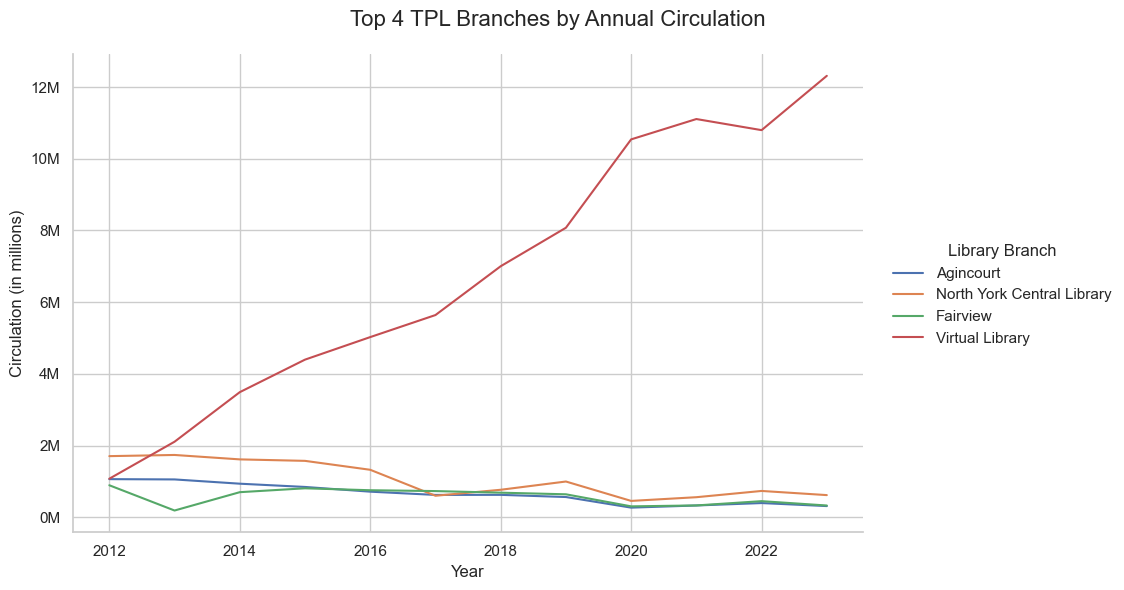

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

#Load the data
url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/80f89d58-fc77-41b4-8d7d-c8f056168a6a/resource/d27bb12b-2575-442f-a410-a720e1de09bf/download/tpl-circulation-annual-by-branch.csv"
df = pd.read_csv(url)

#Clean data
df.dropna(subset=["BranchCode", "Year", "Circulation"], inplace=True)

#Find top 4 branches by total circulation
top_branches = (
    df.groupby("BranchCode")["Circulation"]
    .sum()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

#Filter data to top 4 branches
df_top = df[df["BranchCode"].isin(top_branches)].copy()
df_top["BranchName"] = df_top["BranchCode"].map(branch_names)

#Add mapping from BranchCode to full name
branch_names = {
    "AG": "Agincourt",
    "VIR": "Virtual Library",
    "FV": "Fairview",
    "CL": "North York Central Library"
}

#Create new column with full names
df_top["BranchName"] = df_top["BranchCode"].map(branch_names)

#Set plot style
sns.set(style="whitegrid")

#Plot using full branch names for legend
plot = sns.relplot(
    data=df_top,
    x="Year",
    y="Circulation",
    hue="BranchName",  #Use descriptive names here from branch dictionary
    kind="line",
    height=6,
    aspect=1.5
)

# Title and axis labels
plot.fig.suptitle("Top 4 TPL Branches by Annual Circulation", fontsize=16)
plot.set_axis_labels("Year", "Circulation (in millions)")

# Format y-axis to show values in millions
ax = plot.ax
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x / 1_000_000:.0f}M')) #set tickers as whole numbers with M

# Set library legend title
plot._legend.set_title("Library Branch")

# Final layout, save, and show
plot.tight_layout()
plot.fig.savefig("top_tpl_branches.png", dpi=300, bbox_inches="tight")
plt.show()


In [14]:
print(df["Circulation"].max()) #check max number of circulation for y axis

12313520
